# Synthetic checkpoint and statistical analysis

This notebook verifies the frozen analysis pipeline before real experimental
results are produced.

It demonstrates:

- one cumulative 40-query trajectory;
- frozen incumbents at checkpoints 5, 10, 20, and 40;
- hidden-confirmation checkpoint records;
- normalized confirmed AUDC;
- within-gene aggregation across seeds;
- paired gene-level bootstrap inference.

The synthetic values are designed for verification and are not experimental
findings.


In [1]:
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from agenticls_auditor.inference import (
    paired_gene_clustered_bootstrap,
    within_gene_seed_means,
)
from agenticls_auditor.mutations import Candidate
from agenticls_auditor.results import (
    ConfirmationBankReference,
    TrajectorySummary,
    write_jsonl,
)
from agenticls_auditor.search.base import Observation, Policy
from agenticls_auditor.search.trajectory import run_trajectory
from agenticls_auditor.statistics import (
    checkpoint_results_from_trajectory,
    confirmed_naudc,
    summarize_trajectory,
    validate_checkpoint_results,
)

print("Imports successful.")


Imports successful.


## 1. Construct one deterministic 40-query trajectory

The ordered policy evaluates each synthetic candidate once. Its scoring
functions make the incumbent predictable at every checkpoint.


In [2]:
class OrderedPolicy(Policy):
    name = "ordered"

    def choose(
        self,
        candidates: list[Candidate],
        history: list[Observation],
        query_index: int,
    ) -> Candidate:
        return candidates[query_index - 1]


def candidate_number(candidate: Candidate) -> int:
    return int(candidate.sequence.rsplit("-", 1)[1])


candidates = [
    Candidate(
        source_id="synthetic_gene",
        sequence=f"candidate-{index:02d}",
        codon_positions=(index, index + 1),
        depth=2,
    )
    for index in range(1, 41)
]

trajectory = run_trajectory(
    policy=OrderedPolicy(),
    candidates=candidates,
    discovery_score=lambda candidate: -candidate_number(candidate),
    validation_score=lambda candidate: (
        -candidate_number(candidate) - 0.1
    ),
    confirmation_score=lambda candidate: (
        -0.02 * candidate_number(candidate)
    ),
)

assert len(trajectory.events) == 40
assert len({event.candidate_sequence for event in trajectory.events}) == 40

print("Trajectory queries:", len(trajectory.events))
print(
    "Checkpoint schedule:",
    [snapshot.checkpoint for snapshot in trajectory.checkpoints],
)


Trajectory queries: 40
Checkpoint schedule: [5, 10, 20, 40]


## 2. Convert the trajectory into frozen checkpoint records

Hidden confirmation evaluates the incumbent already selected by discovery.
It does not replace that incumbent.


In [3]:
records = checkpoint_results_from_trajectory(
    trajectory=trajectory,
    gene_id="synthetic_gene",
    model="synthetic_model",
    policy="ordered",
    seed=11,
    depth=2,
    delta=0.01,
    confirmation_lookup=lambda sequence: ConfirmationBankReference(
        bank_id=f"hidden-{sequence}",
        control_count=8,
    ),
    commit="synthetic",
)

validate_checkpoint_results(records)

checkpoint_table = pd.DataFrame(
    [asdict(record) for record in records]
)

display(
    checkpoint_table[
        [
            "checkpoint",
            "candidate_sequence",
            "discovery_margin",
            "confirmation_margin",
            "confirmed_severity",
            "candidate_evaluations",
            "validation_actions",
            "confirmation_control_count",
        ]
    ]
)

assert len(records) == 4
assert [row.checkpoint for row in records] == [5, 10, 20, 40]
assert [row.candidate_sequence for row in records] == [
    "candidate-05",
    "candidate-10",
    "candidate-20",
    "candidate-40",
]

expected_severity = [0.09, 0.19, 0.39, 0.79]

for observed, expected in zip(
    [row.confirmed_severity for row in records],
    expected_severity,
):
    assert abs(observed - expected) < 1e-12

print("All checkpoint and schema checks passed.")


,checkpoint,candidate_sequence,discovery_margin,confirmation_margin,confirmed_severity,candidate_evaluations,validation_actions,confirmation_control_count
0,5,candidate-05,-5.0,-0.1,0.09,5,2,8
1,10,candidate-10,-10.0,-0.2,0.19,10,3,8
2,20,candidate-20,-20.0,-0.4,0.39,20,5,8
3,40,candidate-40,-40.0,-0.8,0.79,40,10,8


All checkpoint and schema checks passed.


## 3. Calculate normalized confirmed AUDC

The endpoint integrates confirmed severity over the checkpoint budget and
normalizes over the observed budget interval.


Confirmed severities: [0.09000000000000001, 0.19, 0.39, 0.79]
Normalized confirmed AUDC: 0.44000000000000006
Trajectory summary: {'gene_id': 'synthetic_gene', 'model': 'synthetic_model', 'policy': 'ordered', 'seed': 11, 'depth': 2, 'normalized_confirmed_audc': 0.44000000000000006, 'checkpoint_count': 4, 'commit': 'synthetic', 'schema_version': 1}


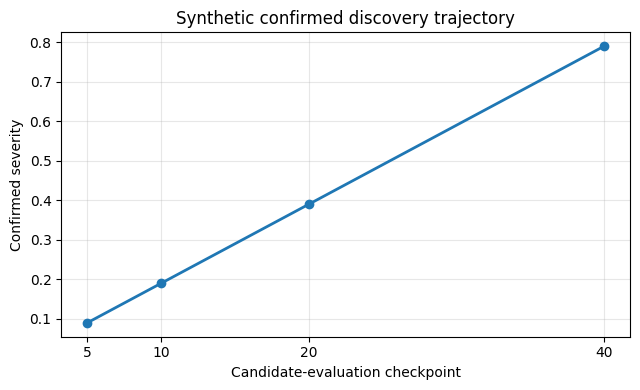

In [4]:
naudc = confirmed_naudc(records)
trajectory_summary = summarize_trajectory(records)

print("Confirmed severities:", [
    row.confirmed_severity for row in records
])
print("Normalized confirmed AUDC:", naudc)
print("Trajectory summary:", asdict(trajectory_summary))

assert abs(naudc - 0.44) < 1e-12
assert trajectory_summary.checkpoint_count == 4
assert (
    abs(
        trajectory_summary.normalized_confirmed_audc
        - 0.44
    )
    < 1e-12
)

plt.figure(figsize=(6.5, 4))
plt.plot(
    [row.checkpoint for row in records],
    [row.confirmed_severity for row in records],
    marker="o",
    linewidth=2,
)
plt.xlabel("Candidate-evaluation checkpoint")
plt.ylabel("Confirmed severity")
plt.title("Synthetic confirmed discovery trajectory")
plt.xticks([5, 10, 20, 40])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Aggregate seeds within each gene

Seeds are repeated measurements within a source gene. They are averaged
inside each gene-policy cell before policies are compared.


In [5]:
SEEDS = (11, 22)

policy_values = {
    "gene-1": {
        "auditor": (0.5, 0.7),
        "random": (0.2, 0.4),
    },
    "gene-2": {
        "auditor": (0.8, 1.0),
        "random": (0.4, 0.6),
    },
    "gene-3": {
        "auditor": (0.3, 0.5),
        "random": (0.2, 0.2),
    },
}

summaries = []

for gene_id, policies in policy_values.items():
    for policy, values in policies.items():
        for seed, value in zip(SEEDS, values):
            summaries.append(
                TrajectorySummary(
                    gene_id=gene_id,
                    model="synthetic-model",
                    policy=policy,
                    seed=seed,
                    depth=2,
                    normalized_confirmed_audc=value,
                    checkpoint_count=4,
                    commit="synthetic",
                )
            )

gene_policy_means = within_gene_seed_means(
    summaries,
    model="synthetic-model",
    depth=2,
    policies=("auditor", "random"),
    expected_seeds=SEEDS,
)

means_table = pd.DataFrame(
    [asdict(row) for row in gene_policy_means]
)

display(means_table)

assert len(gene_policy_means) == 6
assert set(means_table["seed_count"]) == {2}


,gene_id,model,policy,depth,seed_count,mean_normalized_confirmed_audc
0,gene-1,synthetic-model,auditor,2,2,0.6
1,gene-1,synthetic-model,random,2,2,0.3
2,gene-2,synthetic-model,auditor,2,2,0.9
3,gene-2,synthetic-model,random,2,2,0.5
4,gene-3,synthetic-model,auditor,2,2,0.4
5,gene-3,synthetic-model,random,2,2,0.2


## 5. Paired gene-clustered bootstrap

The source gene is the independent unit. The comparison below estimates the
mean paired difference:

\[
\text{auditor nAUDC} - \text{random nAUDC}.
\]

The bootstrap resamples genes, not checkpoints or individual seeds.


Paired bootstrap result:
  model: synthetic-model
  depth: 2
  policy_a: auditor
  policy_b: random
  gene_count: 3
  seeds_per_gene_policy: 2
  mean_difference_a_minus_b: 0.3
  confidence_level: 0.95
  confidence_interval_low: 0.20000000000000004
  confidence_interval_high: 0.4000000000000001
  bootstrap_replicates: 10000
  bootstrap_seed: 2026


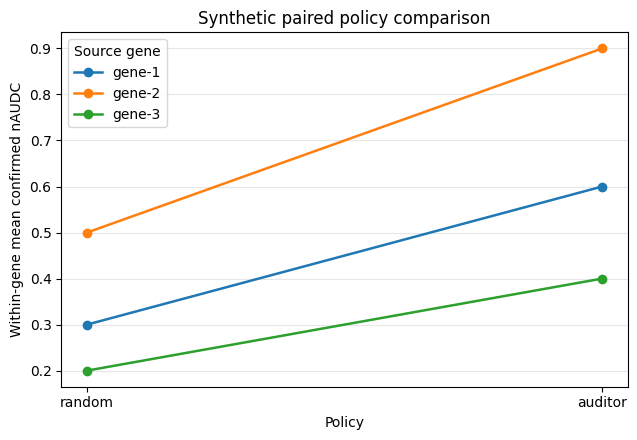

In [6]:
bootstrap_result = paired_gene_clustered_bootstrap(
    summaries,
    model="synthetic-model",
    depth=2,
    policy_a="auditor",
    policy_b="random",
    expected_seeds=SEEDS,
    bootstrap_replicates=10_000,
    confidence_level=0.95,
    bootstrap_seed=2026,
)

print("Paired bootstrap result:")
for key, value in asdict(bootstrap_result).items():
    print(f"  {key}: {value}")

assert bootstrap_result.gene_count == 3
assert bootstrap_result.seeds_per_gene_policy == 2
assert abs(
    bootstrap_result.mean_difference_a_minus_b - 0.3
) < 1e-12
assert (
    bootstrap_result.confidence_interval_low
    <= bootstrap_result.mean_difference_a_minus_b
    <= bootstrap_result.confidence_interval_high
)

wide = means_table.pivot(
    index="gene_id",
    columns="policy",
    values="mean_normalized_confirmed_audc",
)

plt.figure(figsize=(6.5, 4.5))

for gene_id, row in wide.iterrows():
    plt.plot(
        ["random", "auditor"],
        [row["random"], row["auditor"]],
        marker="o",
        linewidth=1.8,
        label=gene_id,
    )

plt.ylabel("Within-gene mean confirmed nAUDC")
plt.xlabel("Policy")
plt.title("Synthetic paired policy comparison")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Source gene")
plt.tight_layout()
plt.show()


## 6. Write schema-valid synthetic outputs

These files are temporary notebook outputs used to verify serialization.
Real development and locked experimental results belong in the configured
external results directories.


In [7]:
output_root = Path("/content/agenticls_statistics_synthetic")
output_root.mkdir(parents=True, exist_ok=True)

checkpoint_path = output_root / "checkpoints.jsonl"
summary_path = output_root / "trajectory_summary.jsonl"

write_jsonl(checkpoint_path, records)
write_jsonl(summary_path, [trajectory_summary])

print("Checkpoint file:", checkpoint_path)
print("Summary file:", summary_path)
print("Checkpoint records:", len(checkpoint_path.read_text().splitlines()))
print("Summary records:", len(summary_path.read_text().splitlines()))

assert len(checkpoint_path.read_text().splitlines()) == 4
assert len(summary_path.read_text().splitlines()) == 1

print("\nAll synthetic statistical-analysis checks passed.")


Checkpoint file: /content/agenticls_statistics_synthetic/checkpoints.jsonl
Summary file: /content/agenticls_statistics_synthetic/trajectory_summary.jsonl
Checkpoint records: 4
Summary records: 1

All synthetic statistical-analysis checks passed.


## Frozen statistical plan

- Primary depth: `k=2`.
- Primary endpoint: normalized confirmed AUDC.
- Checkpoints: 5, 10, 20, and 40 candidate evaluations.
- Independent unit: source gene.
- Seeds: averaged within each gene-policy cell.
- Policy comparisons: paired on the identical set of eligible genes.
- Uncertainty: paired gene-clustered bootstrap.
- Primary contrasts: auditor versus random and auditor versus fixed multistage.
- Discovery, online validation, and hidden confirmation remain disjoint.
- Checkpoints and seeds are not treated as independent samples.
- Diagnostic and secondary depths are reported separately from the primary
  `k=2` analysis.
